$$
\text{Na célula de código abaixo, foram importadas as bibliotecas necessárias e os parâmetros do sistema de 1GDL referentes à questão número 1 da lista.}
$$



In [ ]:
#222014714 Erico Lopes de Souza
#Lista 1 27/11/2024
import numpy as np
from math import sin
from math import cos
from math import pi
from scipy.integrate import odeint
from matplotlib import pyplot as plt
from numpy.fft import fft, ifft
from scipy.signal import find_peaks
from math import sin
from math import cos
from math import exp, sqrt, atan2

# parametros e suas unidades

m = 10                          # kg
k = 1000                        # N/m
c= 4                            #Nm/s
wn = np.sqrt(k/m)                # frequencia natural
A = 1                            # Amplitude
phi = 0                          # fase
delta = 0.001
time = np.arange(0.0,6.5, delta)   # time [s] (Vetor tempo de 0s ate 3s com saltos de 0.001s)
#t = np.linspace(0,3,300, endpoint=True)
Tp = 2*pi/wn                     # período
ksi=c/(2*wn*m)
t=3
xi = (c/m)/(2*wn)
wd = wn*sqrt(1-xi**2)
print(ksi)

0.02


Para responder ao item **a)** da questão 1, precisamos calcular a frequência natural \\( \omega_n \\) e a razão de amortecimento \\( \xi \\) do sistema de 1GDL, que são dadas por, respectivamente:


$$
\omega_n = \sqrt{\frac{k}{m}}
$$

$$
\xi = \frac{c}{2\sqrt{km}}
$$

Onde:
- \(k\): constante de rigidez (N/m),
- \(m\): massa do sistema (kg),
- \(c\): coeficiente de amortecimento (N·s/m).

E a equacao governante do sistema e dada por:

$$
𝑚𝑢̈(𝑡) + 𝑐𝑢̇(𝑡) + 𝑘𝑢(𝑡) = 0
$$

Ao rodar a celula de codigo abaixo, o console devera retornar a frequencia natural do sistema de 1GDL bem como a razao de amortecimento.


In [ ]:
# ITEM A:#

print("Frequencia natural igual a ", wn, "Razao de amortecimento do sistema igual a ", ksi)

Frequencia natural igual a  10.0 Razao de amortecimento do sistema igual a  0.02


Em seguida, a solução analítica do problema foi calculada usando-se como base o livro de vibrações da professora Aline, e os resultados foram plotados nos gráficos abaixo:

- **Deslocamento em função do tempo**
- **Velocidade em função do tempo**

As equacoes analitcas sao dadas por:

A equação do deslocamento \( u(t) \):

$$
u(t) = A \exp(-\xi \omega_n t) \cos(\omega_d t - \phi)
$$

Já a equação da velocidade \( v(t) \):

$$
v(t) = -A \exp(-\xi \omega_n t) \left( -\xi \omega_n \cos(\omega_d t - \phi) + \omega_d \sin(\omega_d t - \phi) \right)
$$


Ao rodar a celula de codigo abaixo, ambos os resultados analiticos devem ser plotados em funcao do tempo.




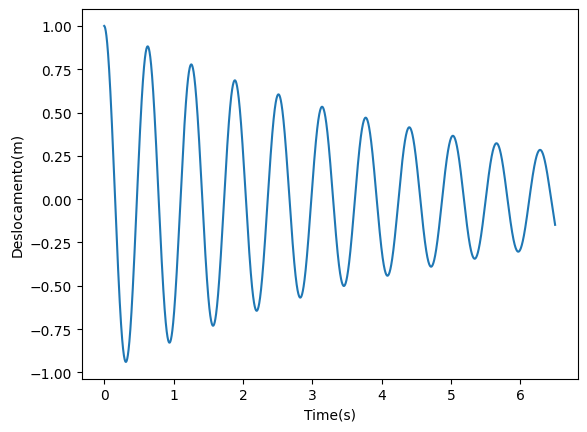

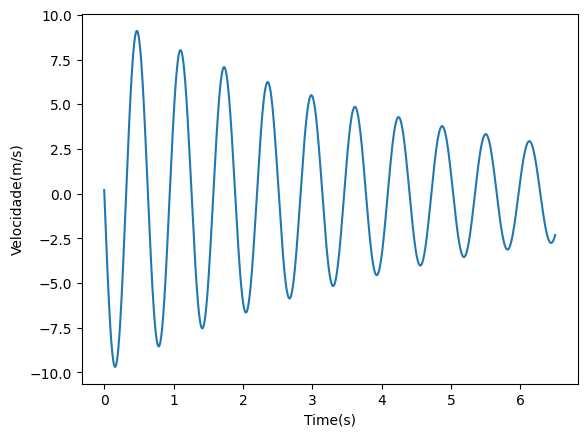

In [ ]:
#  Solucao analitica
u = [ A*exp(-xi*wn*t)*cos(wd*t-phi) for t in time]    #deslocamento
v = [-A*exp(-xi*wn*t)*((-xi*wn)*cos(wd*t-phi)+(wd)*sin(wd*t-phi)) for t in time]     #velocidade

#Plot da solucao analitica

plt.figure()
plt.plot(time,u)
plt.xlabel('Time(s)')
plt.ylabel('Deslocamento(m)')
plt.show()

plt.figure()
plt.plot(time,v)
plt.xlabel('Time(s)')
plt.ylabel('Velocidade(m/s)')
plt.show()

Utilizando um integrador no tempo (EDO de segunda ordem), a solução numérica para o sistema foi calculada e, novamente, as soluções foram plotadas nos gráficos de **velocidade** e **deslocamento** em função do tempo.
A abordagem numérica utilizada foi de  converter essa equação de segunda ordem em um sistema de equações de primeira ordem. Para tal, foi definido um vetor de estado
𝑋
, sendo ele:

 \begin{bmatrix} \dot{x}
 \\ \ddot{x}
 \end{bmatrix}

 Isso resulta em duas equações diferenciais de primeira ordem:

$$
 \dot{u}(t) = v(t)
$$

$$
\dot{v}(t)= -\frac{k}{m} u(t)- \frac{c}{m}v(t)
$$

Agora, numericamente, esse sistema pode ser resolvido utilizando métodos de integração (como o de Runge-Kutta).

Ao rodar a celula de codigo abaixo, a solucao grafica numerica para o deslocamento e velocidade em funcao do tempo numerica devem ser plotadas.









[[ 1.          0.        ]
 [ 0.99995001 -0.09997832]
 [ 0.99980006 -0.19990668]
 ...
 [-0.13890736 -2.31903053]
 [-0.14121894 -2.30409946]
 [-0.14351548 -2.288944  ]]


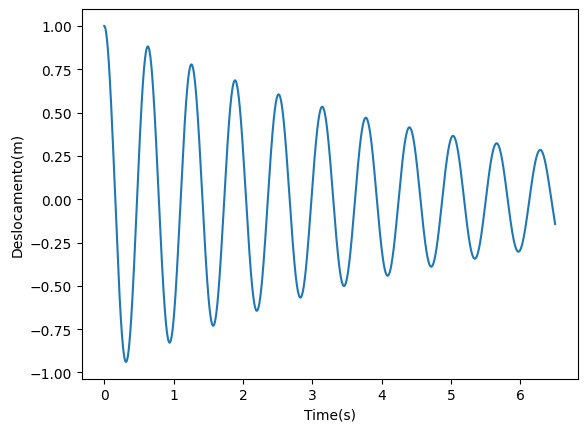

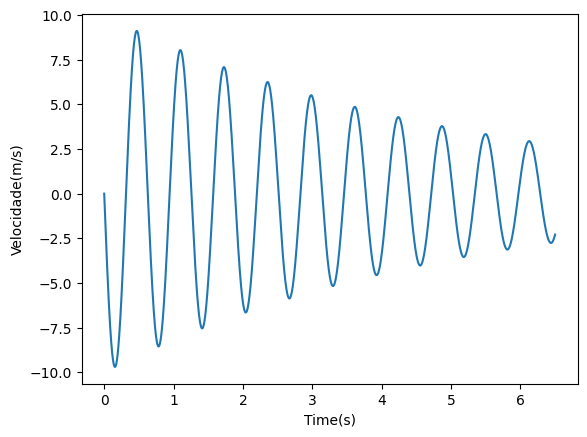

In [ ]:

#Solucao numerica utilizando integrador no tempo (EDO de segunda ordem)

#definindo a funcao

def sistemVibL(y,t):
    xp = y[1]
    xpp = -k/m * y[0] -c/m * y[1] #+ F/m
    dy = [xp, xpp]
    return dy

#Condicoes iniciais

ui = 1.0
vi = 0.0

#Solucoes numericas para velocidade e deslocamento

uvnum = odeint(sistemVibL, [ui,vi], time)

print(uvnum)

# Plotando os resultados
plt.figure()
plt.plot(time,uvnum[:,0])
plt.xlabel('Time(s)')
plt.ylabel('Deslocamento(m)')
plt.show()

plt.figure()
plt.plot(time,uvnum[:,1])
plt.xlabel('Time(s)')
plt.ylabel('Velocidade(m/s)')
plt.show()

Em seguida, a solução analítica e a solução numérica para os primeiros 10 periodos foram comparadas e, com este fito, os graficos de deslocamento numerico e analitico foram plotados juntos (sobrepostos) e o mesmo foi feito para os graficos de velocidade. Rodando a celula do codigo abaixo, os graficos devem ser plotados

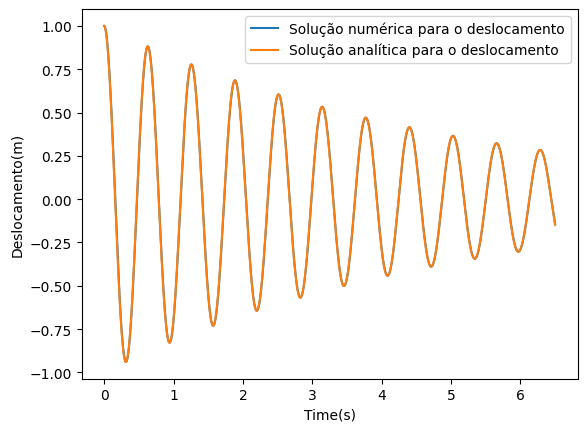

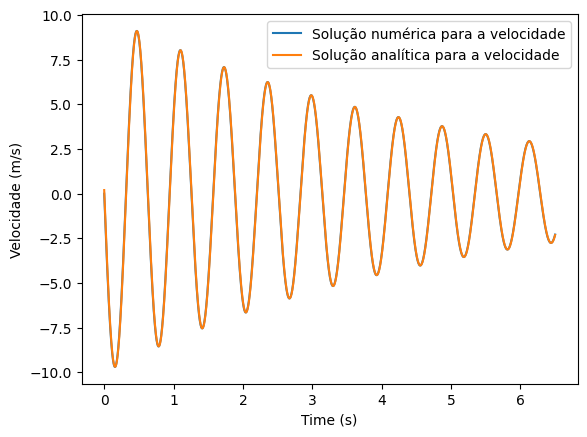

In [ ]:
#comparacao da sol. analitca e num para o deslocamento

plt.figure()
plt.plot(time,uvnum[:,0],label="Solução numérica para o deslocamento")
plt.plot(time,u,label='Solução analítica para o deslocamento')
plt.xlabel('Time(s)')
plt.ylabel('Deslocamento(m)')
plt.legend()
plt.show()


plt.figure()
plt.plot(time, uvnum[:, 1], label="Solução numérica para a velocidade")
plt.plot(time, v, label='Solução analítica para a velocidade')
plt.xlabel('Time (s)')
plt.ylabel('Velocidade (m/s)')
plt.legend()
plt.show()


#comparacao da sol. analitica e num para a velocidade

Como pode-se notar, as solucoes sao extremamente similares.

Em seguida, apliquei a Transformada Rápida de Fourier (utilizando as funçao `numpy.fft.fft`) na solução numérica do deslocamento, conforme solicitado. A análise da transformada permitiu estimar a frequência amortecida do sinal oscilatório amortecido. A frequência obtida foi comparada com a frequência natural do sistema, observando-se a atenuação característica causada pelo amortecimento. O gráfico resultante apresenta o espectro de frequências, evidenciando o pico correspondente à frequência amortecida, que se encontra deslocado em relação à
frequência natural devido ao efeito do amortecimento.



In [ ]:
#Aplicando a transformada rapida de fourrier na solucao numerica

u_frq = np.fft.fft(uvnum[:,0])
n = len(uvnum[:,0])
nhalf = int(np.floor(n/2))
frq = np.fft.fftfreq(n, d=delta)

plt.figure(5)
plt.stem(frq[0:nhalf-1],np.abs(u_frq[0:nhalf-1]))
plt.xlabel('Frequence (Hz)')
plt.ylabel('abs(U) (m/s)')
plt.xlim(0,120)


u_frq_max = np.max(abs(u_frq))
peaks_index, properties = find_peaks(np.abs(u_frq),height = u_frq_max/2)
print('indice pico : ',peaks_index[0])
print('freq. pico',frq[peaks_index[0]])
print('freq. teo:',wn/(2*np.pi))

plt.stem(frq[peaks_index[0]],np.abs(u_frq[peaks_index[0]]),'ro')
plt.xlim([0,5])
plt.show()

NameError: name 'np' is not defined

Agora, para a segunda questao da lista, foi solicitado que os itens  (a), (c), (e)-(f) da questao anterior fossem repetidos, porem, dessa vez, para um problema de 1GDL com atrito seco, com equacao governante dada por:

$$
𝑚𝑢̈(𝑡) + 𝜇 𝑁\frac{|𝑢̇(𝑡)|}{𝑢̇(𝑡)}+ 𝑘𝑢(𝑡) = 0
$$



Novamente, na celula abaixo foram importadas as bibliotecas utilizadas e os parametros do novo sistema.

In [ ]:
#QUESTAO 2

import numpy as np
from math import sin
from math import cos
from math import pi
from scipy.integrate import odeint
from matplotlib import pyplot as plt
from numpy.fft import fft, ifft
from scipy.signal import find_peaks
from math import sin
from math import cos
from math import exp, sqrt, atan2


In [ ]:
# parametros
m = 10                          # kg
k = 1000                        # N/m
c= 4                            #Nm/s
wn = np.sqrt(k/m)                # frequencia natural
A = 1                            # Amplitude
phi = 0                          # fase
delta = 0.001
time = np.arange(0.0,6.5, delta)   # time [s] (Vetor tempo de 0s ate 3s com saltos de 0.001s)
#t = np.linspace(0,3,300, endpoint=True)
Tp = 2*pi/wn                     # período
ksi=c/(2*wn*m)
t=3
xi = (c/m)/(2*wn)
wd = wn*sqrt(1-xi**2)

print("Frequencia natural igual a ", wn, "Razao de amortecimento do sistema igual a ", ksi)


Frequencia natural igual a  10.0 Razao de amortecimento do sistema igual a  0.02


In [ ]:

#Solucao numerica


def sistemVibL(y,t):
    xp = y[1]
    xpp = -k/m * y[0] -(2/np.pi)*np.arctan(1.0e6*y[1]) #+ F/m
    dy = [xp, xpp]
    return dy

#CI

ui = 1.0
vi = 0.0

uvnum = odeint(sistemVibL, [ui,vi], time)

print(uvnum)

[[ 1.          0.        ]
 [ 0.99995046 -0.09899837]
 [ 0.99980196 -0.19798684]
 ...
 [-0.30706494 -4.97563279]
 [-0.31202464 -4.94367805]
 [-0.31695214 -4.91122894]]


Aqui, foram plotadas 2 curvas de deslocamento, uma para o atrito seco (Sistema a ser analisado nessa questao) e para o atrito viscoso (Sistema analisado na questao anterior), com o fito de comparar as 2 curvas e, nota-se, que a curva do atrito viscoso decai mais rapidamente, o que faz sentido matematico uma vez que o atrito viscoso e diretamente proporcional a velocidade do corpo de inercia, a qual decai ao longo do tempo.

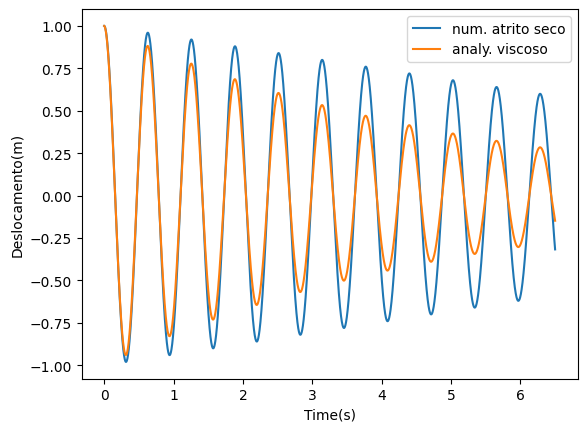

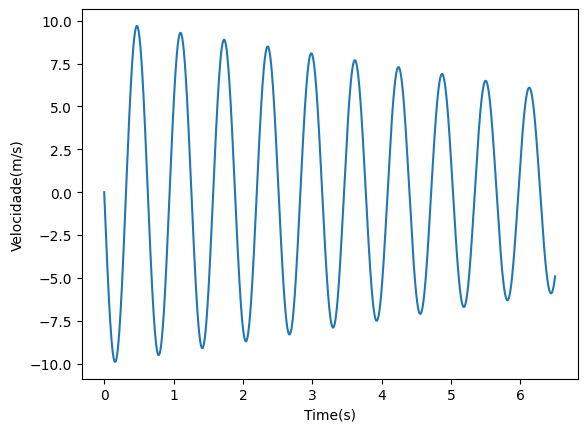

In [ ]:
# Plotando os resultados
plt.figure()
plt.plot(time,uvnum[:,0],label='num. atrito seco')
plt.plot(time,u,label='analy. viscoso')
plt.xlabel('Time(s)')
plt.ylabel('Deslocamento(m)')
plt.legend()
plt.show()

plt.figure()
plt.plot(time,uvnum[:,1])
plt.xlabel('Time(s)')
plt.ylabel('Velocidade(m/s)')
plt.show()

indice pico :  10
freq. pico 1.5384615384615385
freq. teo: 1.5915494309189535


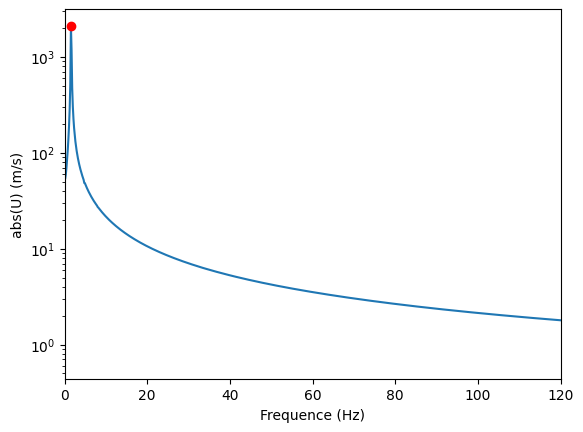

In [ ]:

#Aplicando a transformada rapida de fourrier na solucao numerica


u_frq = np.fft.fft(uvnum[:,0])
n = len(uvnum[:,0])
nhalf = int(np.floor(n/2))
frq = np.fft.fftfreq(n, d=delta)

plt.figure(5)
plt.semilogy(frq[0:nhalf-1],np.abs(u_frq[0:nhalf-1]))
plt.xlabel('Frequence (Hz)')
plt.ylabel('abs(U) (m/s)')
plt.xlim(0,120)


u_frq_max = np.max(abs(u_frq))
peaks_index, properties = find_peaks(np.abs(u_frq),height = u_frq_max/2)
print('indice pico : ',peaks_index[0])
print('freq. pico',frq[peaks_index[0]])
print('freq. teo:',wn/(2*np.pi))

plt.semilogy(frq[peaks_index[0]],np.abs(u_frq[peaks_index[0]]),'ro')
plt.show()
